### 1. IMPORT LIBRARIES

In [2]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

2026-05-31 19:26:15.120202: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 19:26:15.126272: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 19:26:15.218780: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 19:26:17.086637: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 2. DOWNLOAD DATASET

In [3]:

path = kagglehub.dataset_download("feyzazkefe/trashnet")
dataset_dir = os.path.join(path, "dataset-resized")

print("Dataset path:", dataset_dir)
print("Classes:", os.listdir(dataset_dir))

Dataset path: /home/norah/.cache/kagglehub/datasets/feyzazkefe/trashnet/versions/1/dataset-resized
Classes: ['glass', 'metal', 'cardboard', 'paper', 'plastic', 'trash']


## 3. DATASET INFORMATION

In [4]:
class_counts = {}
total_images = 0
image_sizes = {}

for cls in os.listdir(dataset_dir):
    cls_path = os.path.join(dataset_dir, cls)

    if os.path.isdir(cls_path):
        files = os.listdir(cls_path)
        class_counts[cls] = len(files)
        total_images += len(files)

        for img_name in files:
            img_path = os.path.join(cls_path, img_name)

            try:
                img = Image.open(img_path)
                size = img.size
                image_sizes[size] = image_sizes.get(size, 0) + 1
            except:
                pass

print("Images per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", total_images)
print("Number of unique image sizes:", len(image_sizes))

print("\nImage sizes:")
for size, count in image_sizes.items():
    print(f"{size}: {count} images")

Images per class:
glass: 501
metal: 410
cardboard: 403
paper: 594
plastic: 482
trash: 137

Total images: 2527
Number of unique image sizes: 1

Image sizes:
(512, 384): 2527 images


## 4. CLASS DISTRIBUTION GRAPH

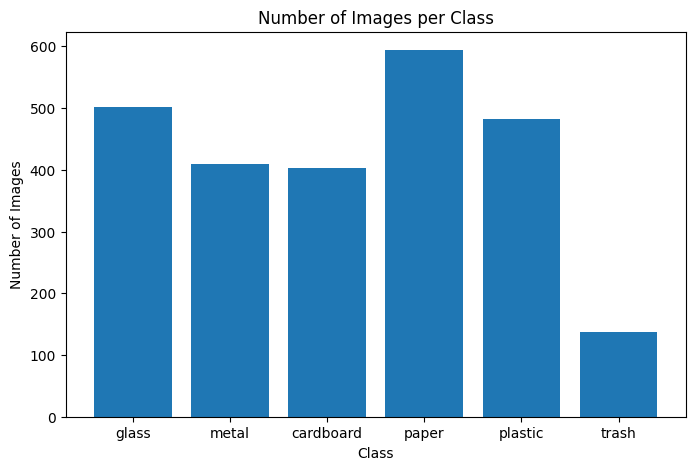

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## 5. VISUALIZE SAMPLE IMAGES

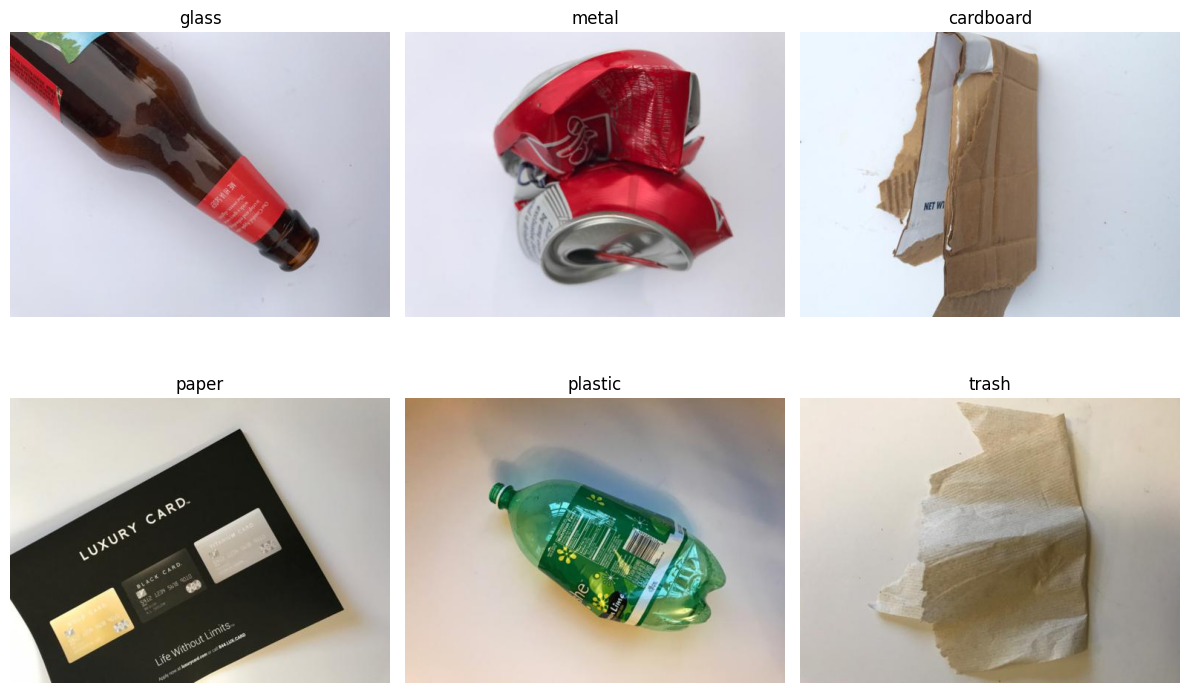

In [6]:
classes = list(class_counts.keys())

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 6. IMAGE PROCESSING FUNCTIONS
# Median Filter and Gaussian Filter
# ============================================================

def median_filter_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))
    
    # Median filter
    img = cv2.medianBlur(img, 3)
    
    img = preprocess_input(img.astype(np.float32))
    return img


def gaussian_filter_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))
    
    # Gaussian filter
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    img = preprocess_input(img.astype(np.float32))
    return img

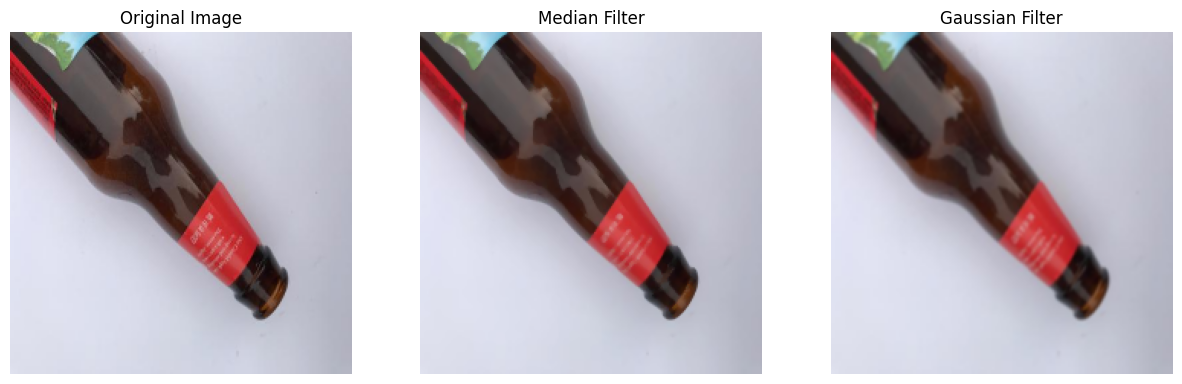

In [10]:
# ============================================================
# 7. VISUALIZE IMAGE PROCESSING EFFECT
# ============================================================

sample_class = classes[0]
sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

median_img = cv2.medianBlur(img, 3)
gaussian_img = cv2.GaussianBlur(img, (3, 3), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median_img)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian_img)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

In [8]:
# ============================================================
# 8. CREATE DATA GENERATORS
# Original vs Median vs Gaussian
# ============================================================

img_size = (224, 224)
batch_size = 32

# Original images
original_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# Median filter images
median_datagen = ImageDataGenerator(
    preprocessing_function=median_filter_preprocess,
    validation_split=0.2
)

# Gaussian filter images
gaussian_datagen = ImageDataGenerator(
    preprocessing_function=gaussian_filter_preprocess,
    validation_split=0.2
)

In [9]:
# ============================================================
# 9. ORIGINAL DATA
# ============================================================

original_train = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

original_val = original_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print("Class indices:", original_train.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [10]:
# ============================================================
# 10. MEDIAN FILTER DATA
# ============================================================

median_train = median_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

median_val = median_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [11]:
# ============================================================
# 11. GAUSSIAN FILTER DATA
# ============================================================

gaussian_train = gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

gaussian_val = gaussian_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [12]:
# ============================================================
# 12. BUILD MobileNetV2 CLASSIFIER
# ============================================================

def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
# ============================================================
# 13. TRAIN ORIGINAL MODEL
# ============================================================

original_model = build_model()

original_history = original_model.fit(
    original_train,
    validation_data=original_val,
    epochs=10
)

Epoch 1/10
 3/64 ━━━━━━━━━━━━━━━━━━━━ 42s 701ms/step - accuracy: 0.2188 - loss: 2.1068

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 14. TRAIN MEDIAN FILTER MODEL
# ============================================================

median_model = build_model()

median_history = median_model.fit(
    median_train,
    validation_data=median_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 984ms/step - accuracy: 0.6601 - loss: 0.9418 - val_accuracy: 0.6998 - val_loss: 0.7522
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 883ms/step - accuracy: 0.8192 - loss: 0.5052 - val_accuracy: 0.7276 - val_loss: 0.7256
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 859ms/step - accuracy: 0.8602 - loss: 0.3882 - val_accuracy: 0.7396 - val_loss: 0.7596
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.8770 - loss: 0.3149 - val_accuracy: 0.7217 - val_loss: 0.7259
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 862ms/step - accuracy: 0.9042 - loss: 0.2715 - val_accuracy: 0.7256 - val_loss: 0.7710
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 830ms/step - accuracy: 0.9239 - loss: 0.2193 - val_accuracy: 0.7237 - val_loss: 0.8400
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 819ms/step - accuracy: 0.9308 - loss: 0.1952 - val_accuracy: 0.7594 - val_loss: 0.7933
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 808ms/step - accuracy: 0.9427 - loss: 0.1632 - val_accu

In [ ]:
# ============================================================
# 15. TRAIN GAUSSIAN FILTER MODEL
# ============================================================

gaussian_model = build_model()

gaussian_history = gaussian_model.fit(
    gaussian_train,
    validation_data=gaussian_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 903ms/step - accuracy: 0.6621 - loss: 0.8988 - val_accuracy: 0.7157 - val_loss: 0.7312
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - accuracy: 0.8103 - loss: 0.5075 - val_accuracy: 0.7594 - val_loss: 0.6491
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 861ms/step - accuracy: 0.8587 - loss: 0.3790 - val_accuracy: 0.7217 - val_loss: 0.7387
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 866ms/step - accuracy: 0.8898 - loss: 0.3106 - val_accuracy: 0.7435 - val_loss: 0.7093
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.9071 - loss: 0.2571 - val_accuracy: 0.7634 - val_loss: 0.7008
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 867ms/step - accuracy: 0.9229 - loss: 0.2156 - val_accuracy: 0.7674 - val_loss: 0.6833
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 838ms/step - accuracy: 0.9382 - loss: 0.1818 - val_accuracy: 0.7674 - val_loss: 0.7282
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 831ms/step - accuracy: 0.9481 - loss: 0.1569 - val_accu

In [ ]:
# ============================================================
# 16. COMPARE RESULTS
# ============================================================

original_acc = original_history.history["val_accuracy"][-1]
median_acc = median_history.history["val_accuracy"][-1]
gaussian_acc = gaussian_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Median Filter Validation Accuracy:", median_acc)
print("Gaussian Filter Validation Accuracy:", gaussian_acc)

print("\nMedian Improvement:", median_acc - original_acc)
print("Gaussian Improvement:", gaussian_acc - original_acc)

Original Images Validation Accuracy: 0.7574552893638611
Median Filter Validation Accuracy: 0.7614313960075378
Gaussian Filter Validation Accuracy: 0.781312108039856

Median Improvement: 0.003976106643676758
Gaussian Improvement: 0.023856818675994873


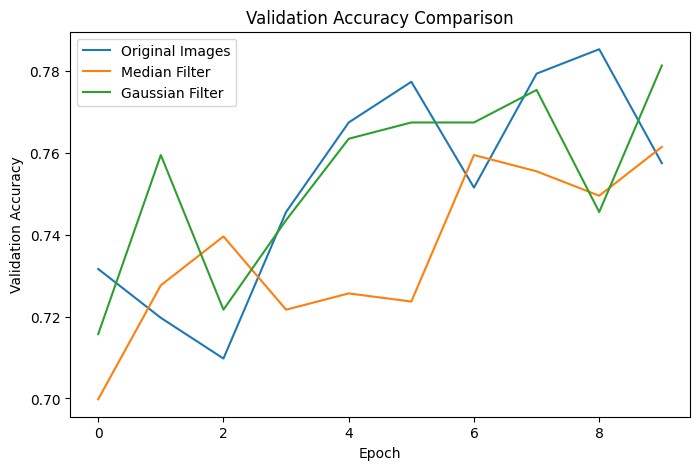

In [ ]:
# ============================================================
# 17. PLOT VALIDATION ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(original_history.history["val_accuracy"], label="Original Images")
plt.plot(median_history.history["val_accuracy"], label="Median Filter")
plt.plot(gaussian_history.history["val_accuracy"], label="Gaussian Filter")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

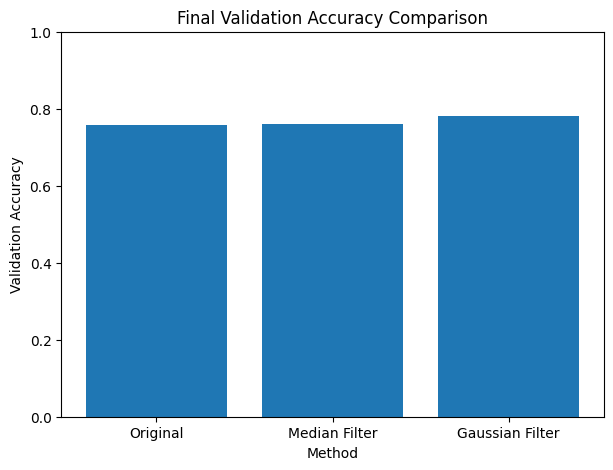

In [ ]:
# ============================================================
# 18. BAR CHART FINAL ACCURACY
# ============================================================

methods = ["Original", "Median Filter", "Gaussian Filter"]
accuracies = [original_acc, median_acc, gaussian_acc]

plt.figure(figsize=(7, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()

In [ ]:
# ============================================================
# UNSHARP MASKING + HIGH-BOOST PREPROCESSING FUNCTIONS
# ============================================================

def unsharp_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Blur image
    blurred = cv2.GaussianBlur(img, (5, 5), 1)

    # Unsharp masking
    sharpened = cv2.addWeighted(
        img, 1.5,
        blurred, -0.5,
        0
    )

    img = preprocess_input(sharpened.astype(np.float32))
    return img


def highboost_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Blur image
    blurred = cv2.GaussianBlur(img, (5, 5), 1)

    # High-boost filtering
    highboost = cv2.addWeighted(
        img, 2.0,
        blurred, -1.0,
        0
    )

    img = preprocess_input(highboost.astype(np.float32))
    return img

In [ ]:
unsharp_datagen = ImageDataGenerator(
    preprocessing_function=unsharp_preprocess,
    validation_split=0.2
)

highboost_datagen = ImageDataGenerator(
    preprocessing_function=highboost_preprocess,
    validation_split=0.2
)

In [ ]:
unsharp_train = unsharp_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

unsharp_val = unsharp_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
highboost_train = highboost_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

highboost_val = highboost_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


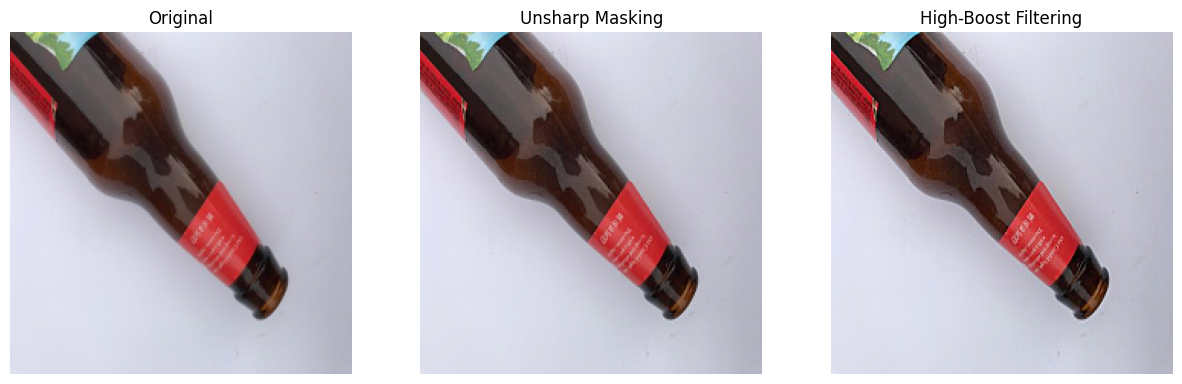

In [ ]:
sample_class = classes[0]
sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

blurred = cv2.GaussianBlur(img, (5, 5), 1)
unsharp_img = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
highboost_img = cv2.addWeighted(img, 2.0, blurred, -1.0, 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(unsharp_img)
plt.title("Unsharp Masking")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(highboost_img)
plt.title("High-Boost Filtering")
plt.axis("off")

plt.show()

In [ ]:
unsharp_model = build_model()

unsharp_history = unsharp_model.fit(
    unsharp_train,
    validation_data=unsharp_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 900ms/step - accuracy: 0.6749 - loss: 0.8920 - val_accuracy: 0.7058 - val_loss: 0.7013
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.8330 - loss: 0.4599 - val_accuracy: 0.7416 - val_loss: 0.6924
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 832ms/step - accuracy: 0.8814 - loss: 0.3315 - val_accuracy: 0.7058 - val_loss: 0.7731
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 907ms/step - accuracy: 0.8997 - loss: 0.2808 - val_accuracy: 0.7714 - val_loss: 0.6484
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 858ms/step - accuracy: 0.9145 - loss: 0.2268 - val_accuracy: 0.7594 - val_loss: 0.6593
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 843ms/step - accuracy: 0.9333 - loss: 0.1793 - val_accuracy: 0.7753 - val_loss: 0.6954
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 864ms/step - accuracy: 0.9452 - loss: 0.1687 - val_accuracy: 0.7634 - val_loss: 0.7048
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 847ms/step - accuracy: 0.9639 - loss: 0.1224 - val_accu

In [ ]:
highboost_model = build_model()

highboost_history = highboost_model.fit(
    highboost_train,
    validation_data=highboost_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 874ms/step - accuracy: 0.6640 - loss: 0.9122 - val_accuracy: 0.7555 - val_loss: 0.7434
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.8261 - loss: 0.4700 - val_accuracy: 0.7575 - val_loss: 0.6676
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 853ms/step - accuracy: 0.8602 - loss: 0.3988 - val_accuracy: 0.7913 - val_loss: 0.6581
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 837ms/step - accuracy: 0.8908 - loss: 0.2939 - val_accuracy: 0.7316 - val_loss: 0.8082
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 827ms/step - accuracy: 0.9234 - loss: 0.2254 - val_accuracy: 0.7714 - val_loss: 0.6820
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 830ms/step - accuracy: 0.9254 - loss: 0.1947 - val_accuracy: 0.7535 - val_loss: 0.6799
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 824ms/step - accuracy: 0.9373 - loss: 0.1722 - val_accuracy: 0.7674 - val_loss: 0.7147
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 834ms/step - accuracy: 0.9531 - loss: 0.1404 - val_accu

In [ ]:
original_acc = original_history.history["val_accuracy"][-1]
median_acc = median_history.history["val_accuracy"][-1]
gaussian_acc = gaussian_history.history["val_accuracy"][-1]
unsharp_acc = unsharp_history.history["val_accuracy"][-1]
highboost_acc = highboost_history.history["val_accuracy"][-1]

print("Original Images Validation Accuracy:", original_acc)
print("Median Filter Validation Accuracy:", median_acc)
print("Gaussian Filter Validation Accuracy:", gaussian_acc)
print("Unsharp Masking Validation Accuracy:", unsharp_acc)
print("High-Boost Filtering Validation Accuracy:", highboost_acc)

print("\nGaussian Improvement:", gaussian_acc - original_acc)
print("Unsharp Improvement:", unsharp_acc - original_acc)
print("High-Boost Improvement:", highboost_acc - original_acc)

Original Images Validation Accuracy: 0.7574552893638611
Median Filter Validation Accuracy: 0.7614313960075378
Gaussian Filter Validation Accuracy: 0.781312108039856
Unsharp Masking Validation Accuracy: 0.7594433426856995
High-Boost Filtering Validation Accuracy: 0.737574577331543

Gaussian Improvement: 0.023856818675994873
Unsharp Improvement: 0.001988053321838379
High-Boost Improvement: -0.019880712032318115


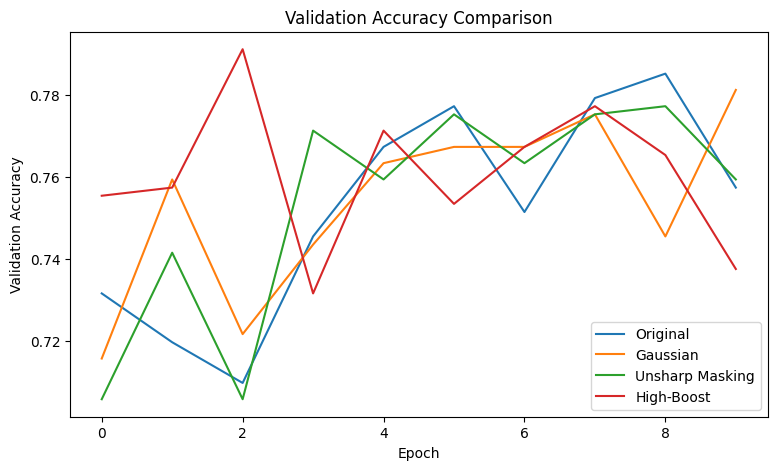

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(original_history.history["val_accuracy"], label="Original")
plt.plot(gaussian_history.history["val_accuracy"], label="Gaussian")
plt.plot(unsharp_history.history["val_accuracy"], label="Unsharp Masking")
plt.plot(highboost_history.history["val_accuracy"], label="High-Boost")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

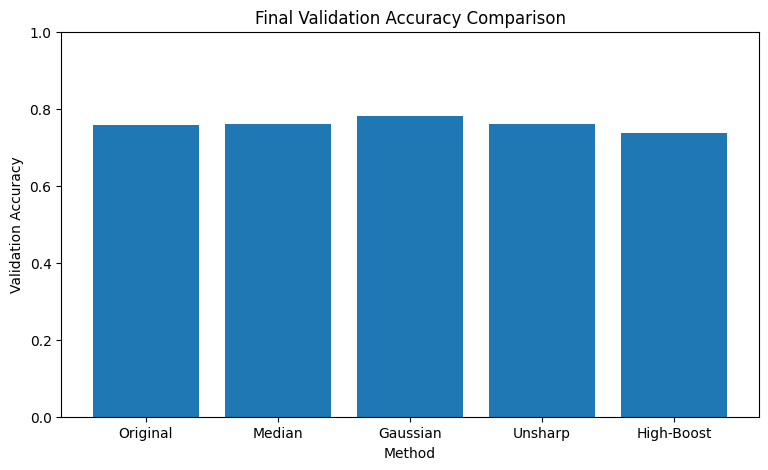

In [ ]:
methods = [
    "Original",
    "Median",
    "Gaussian",
    "Unsharp",
    "High-Boost"
]

accuracies = [
    original_acc,
    median_acc,
    gaussian_acc,
    unsharp_acc,
    highboost_acc
]

plt.figure(figsize=(9, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()

Gaussian filtering achieved the highest validation accuracy of 78.13%, compared to 75.75% for the original images. This shows that image preprocessing improved the CNN classification performance by reducing minor image variations while preserving the main object structure. However, high-boost filtering decreased accuracy because excessive sharpening may amplify edges and noise, making classification less stable.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = gaussian_val.classes
y_pred_probs = gaussian_model.predict(gaussian_val)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(gaussian_val.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 926ms/step
              precision    recall  f1-score   support

   cardboard       0.92      0.72      0.81        80
       glass       0.73      0.84      0.78       100
       metal       0.76      0.87      0.81        82
       paper       0.80      0.91      0.85       118
     plastic       0.76      0.66      0.70        96
       trash       0.67      0.37      0.48        27

    accuracy                           0.78       503
   macro avg       0.77      0.73      0.74       503
weighted avg       0.78      0.78      0.78       503

[[ 58   1   2  15   2   2]
 [  0  84  10   2   4   0]
 [  0   5  71   2   4   0]
 [  5   2   1 107   2   1]
 [  0  23   5   3  63   2]
 [  0   0   4   5   8  10]]


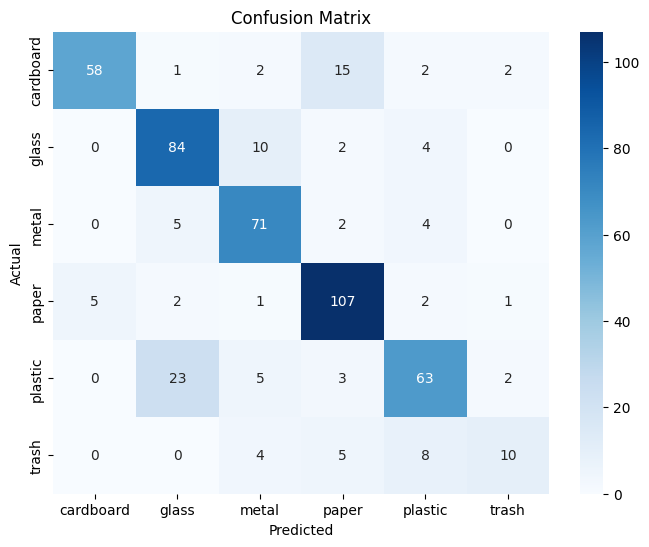

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The Gaussian-filtered MobileNetV2 model achieved an overall accuracy of 78%. The weighted average precision, recall, and F1-score were all 0.78, showing good and balanced performance across most classes.

The paper class had the best result with an F1-score of 0.85. Cardboard and metal also performed well, each with an F1-score of 0.81. The trash class had the lowest performance with an F1-score of 0.48 because it had fewer training images and looked similar to other waste categories.

The confusion matrix showed that most mistakes happened between plastic and glass because both often contain transparent objects that look alike.

Overall, applying the Gaussian filter improved the model’s performance compared to using the original images, showing that image preprocessing can help improve waste classification.


### Gaussian Filter = 78.13%

compare to:

### Original = 75.75%

the improvement :

### +2.38%

the final ranking:

1. **Gaussian Filter** = 78.13%
2. Median Filter = 76.14%
3. Unsharp Masking = 75.94%
4. Original = 75.75%
5. High-Boost = 73.75%

conclusion:

> Gaussian filtering achieved the best performance because it reduced minor image variations and background noise while preserving the overall structure of the waste objects. In contrast, high-boost filtering reduced accuracy because excessive sharpening may amplify edges and noise, making the model less stable.

so the Gaussian filter is the best to use as a preprocessing method


---------------------------
## Morphological Preprocessing Function

In [ ]:
def morphology_preprocess(img):
    img = img.astype(np.uint8)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Otsu Threshold
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Structuring element
    kernel = np.ones((5, 5), np.uint8)

    # Opening
    opened = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    closed = cv2.morphologyEx(
        opened,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Apply mask to original image
    segmented = cv2.bitwise_and(
        img,
        img,
        mask=closed
    )

    # MobileNetV2 preprocessing
    segmented = preprocess_input(
        segmented.astype(np.float32)
    )

    return segmented

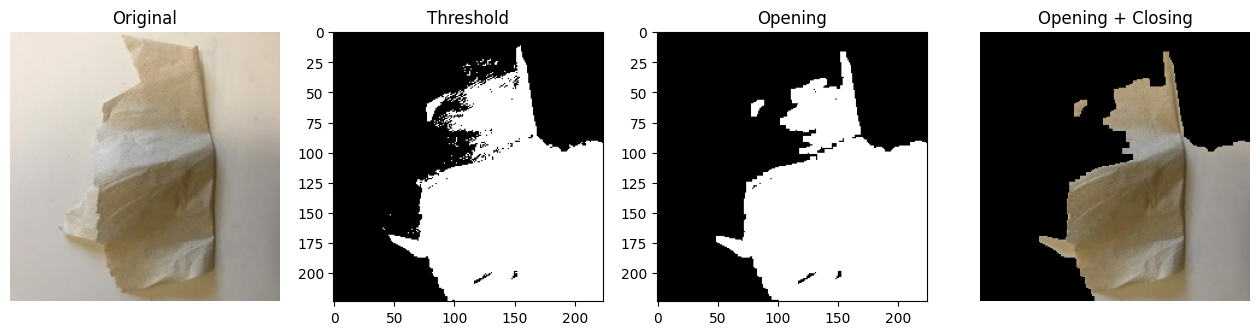

In [16]:
sample_class = classes[5]

sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((5,5), np.uint8)

opened = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

closed = cv2.morphologyEx(
    opened,
    cv2.MORPH_CLOSE,
    kernel
)

segmented = cv2.bitwise_and(
    img,
    img,
    mask=closed
)

plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(binary, cmap="gray")
plt.title("Threshold")

plt.subplot(1,4,3)
plt.imshow(opened, cmap="gray")
plt.title("Opening")

plt.subplot(1,4,4)
plt.imshow(segmented)
plt.title("Opening + Closing")
plt.axis("off")

plt.show()

In [ ]:
morph_datagen = ImageDataGenerator(
    preprocessing_function=morphology_preprocess,
    validation_split=0.2
)

morph_train = morph_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

morph_val = morph_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
morph_model = build_model()

morph_history = morph_model.fit(
    morph_train,
    validation_data=morph_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 987ms/step - accuracy: 0.5455 - loss: 1.1876 - val_accuracy: 0.6044 - val_loss: 1.0408
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 922ms/step - accuracy: 0.7050 - loss: 0.7755 - val_accuracy: 0.6342 - val_loss: 0.9850
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 874ms/step - accuracy: 0.7638 - loss: 0.6500 - val_accuracy: 0.6282 - val_loss: 1.0189
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 865ms/step - accuracy: 0.7974 - loss: 0.5752 - val_accuracy: 0.6501 - val_loss: 0.9927
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 898ms/step - accuracy: 0.8004 - loss: 0.5355 - val_accuracy: 0.6561 - val_loss: 0.9435
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 884ms/step - accuracy: 0.8325 - loss: 0.4602 - val_accuracy: 0.6342 - val_loss: 1.0651
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 848ms/step - accuracy: 0.8508 - loss: 0.4107 - val_accuracy: 0.6541 - val_loss: 0.9723
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 858ms/step - accuracy: 0.8676 - loss: 0.3777 - val_accu

In [ ]:
morph_acc = morph_history.history["val_accuracy"][-1]

print("Original:", original_acc)
print("Gaussian:", gaussian_acc)
print("Morphology:", morph_acc)

Original: 0.7574552893638611
Gaussian: 0.781312108039856
Morphology: 0.6421471238136292


In [15]:
# ============================================================
# 1. HISTOGRAM EQUALIZATION PREPROCESSING
# ============================================================

def histogram_equalization_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Convert RGB to YCrCb
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

    # Equalize brightness channel only
    ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])

    # Convert back to RGB
    enhanced = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

    enhanced = preprocess_input(enhanced.astype(np.float32))
    return enhanced

In [16]:
# ============================================================
# 2. GAUSSIAN + CANNY EDGE ENHANCEMENT PREPROCESSING
# ============================================================

def gaussian_canny_preprocess(img):
    img = img.astype(np.uint8)
    img = cv2.resize(img, (224, 224))

    # Gaussian smoothing
    blurred = cv2.GaussianBlur(img, (3, 3), 0)

    # Convert to grayscale
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)

    # Canny edge detection
    edges = cv2.Canny(gray, 100, 200)

    # Convert edges to RGB
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

    # Combine original image with edge map
    enhanced = cv2.addWeighted(
        blurred,
        0.85,
        edges_rgb,
        0.15,
        0
    )

    enhanced = preprocess_input(enhanced.astype(np.float32))
    return enhanced

In [17]:
# ============================================================
# 3. CREATE DATA GENERATORS
# ============================================================

hist_datagen = ImageDataGenerator(
    preprocessing_function=histogram_equalization_preprocess,
    validation_split=0.2
)

canny_datagen = ImageDataGenerator(
    preprocessing_function=gaussian_canny_preprocess,
    validation_split=0.2
)

In [18]:
# Histogram Equalization data
hist_train = hist_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

hist_val = hist_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [19]:
# Gaussian + Canny data
canny_train = canny_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

canny_val = canny_datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


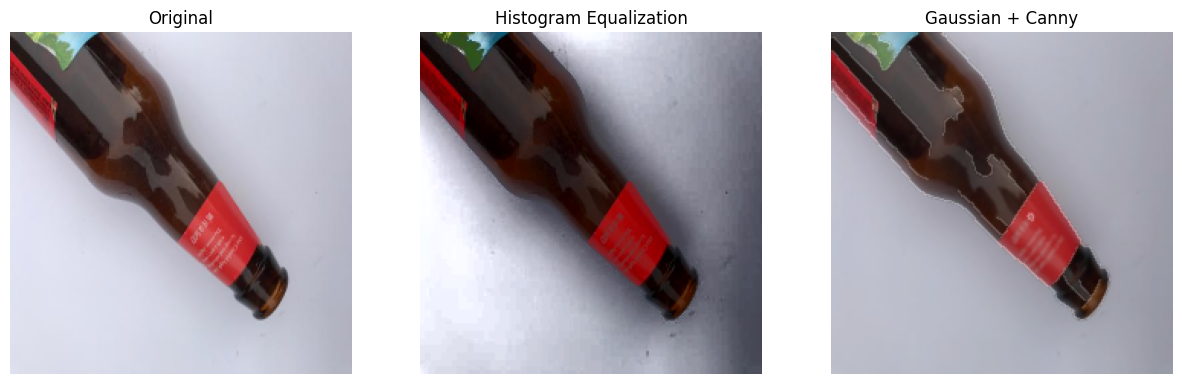

In [20]:
# ============================================================
# 4. VISUALIZE BOTH PREPROCESSING TECHNIQUES
# ============================================================

sample_class = classes[0]
sample_path = os.path.join(
    dataset_dir,
    sample_class,
    os.listdir(os.path.join(dataset_dir, sample_class))[0]
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

# Histogram Equalization
ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
hist_img = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

# Gaussian + Canny
blurred = cv2.GaussianBlur(img, (3, 3), 0)
gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 100, 200)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
canny_img = cv2.addWeighted(blurred, 0.85, edges_rgb, 0.15, 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hist_img)
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_img)
plt.title("Gaussian + Canny")
plt.axis("off")

plt.show()

In [21]:
# ============================================================
# 5. TRAIN HISTOGRAM EQUALIZATION MODEL
# ============================================================

hist_model = build_model()

hist_history = hist_model.fit(
    hist_train,
    validation_data=hist_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 959ms/step - accuracy: 0.6280 - loss: 1.0185 - val_accuracy: 0.6938 - val_loss: 0.8195
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 822ms/step - accuracy: 0.8043 - loss: 0.5717 - val_accuracy: 0.6779 - val_loss: 0.8823
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 817ms/step - accuracy: 0.8360 - loss: 0.4438 - val_accuracy: 0.7038 - val_loss: 0.7975
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 807ms/step - accuracy: 0.8686 - loss: 0.3578 - val_accuracy: 0.7137 - val_loss: 0.8271
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 844ms/step - accuracy: 0.8869 - loss: 0.3170 - val_accuracy: 0.7376 - val_loss: 0.7279
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 819ms/step - accuracy: 0.8893 - loss: 0.2817 - val_accuracy: 0.7177 - val_loss: 0.8527
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 814ms/step - accuracy: 0.9116 - loss: 0.2330 - val_accuracy: 0.7336 - val_loss: 0.7956
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 800ms/step - accuracy: 0.9338 - loss: 0.1912 - val_accu

In [22]:
# ============================================================
# 6. TRAIN GAUSSIAN + CANNY MODEL
# ============================================================

canny_model = build_model()

canny_history = canny_model.fit(
    canny_train,
    validation_data=canny_val,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 893ms/step - accuracy: 0.6245 - loss: 1.0328 - val_accuracy: 0.7117 - val_loss: 0.7878
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 852ms/step - accuracy: 0.7999 - loss: 0.5396 - val_accuracy: 0.7078 - val_loss: 0.7856
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 845ms/step - accuracy: 0.8562 - loss: 0.4204 - val_accuracy: 0.7117 - val_loss: 0.7872
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 888ms/step - accuracy: 0.8775 - loss: 0.3460 - val_accuracy: 0.7455 - val_loss: 0.7900
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 885ms/step - accuracy: 0.8888 - loss: 0.3160 - val_accuracy: 0.7376 - val_loss: 0.8088
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 972ms/step - accuracy: 0.9160 - loss: 0.2533 - val_accuracy: 0.7455 - val_loss: 0.8045
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9190 - loss: 0.2242 - val_accuracy: 0.7455 - val_loss: 0.8796
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 877ms/step - accuracy: 0.9368 - loss: 0.1703 - val_accurac

In [26]:
# ============================================================
# 7. COMPARE ALL RESULTS
# ============================================================

hist_acc = hist_history.history["val_accuracy"][-1]
canny_acc = canny_history.history["val_accuracy"][-1]

#print("Original Images Validation Accuracy:", original_acc)
#print("Gaussian Filter Validation Accuracy:", gaussian_acc)
print("Histogram Equalization Validation Accuracy:", hist_acc)
print("Gaussian + Canny Validation Accuracy:", canny_acc)

#print("\nGaussian Improvement:", gaussian_acc - original_acc)
#print("Histogram Improvement:", hist_acc - original_acc)
#print("Gaussian + Canny Improvement:", canny_acc - original_acc)

Histogram Equalization Validation Accuracy: 0.7335984110832214
Gaussian + Canny Validation Accuracy: 0.7554671764373779


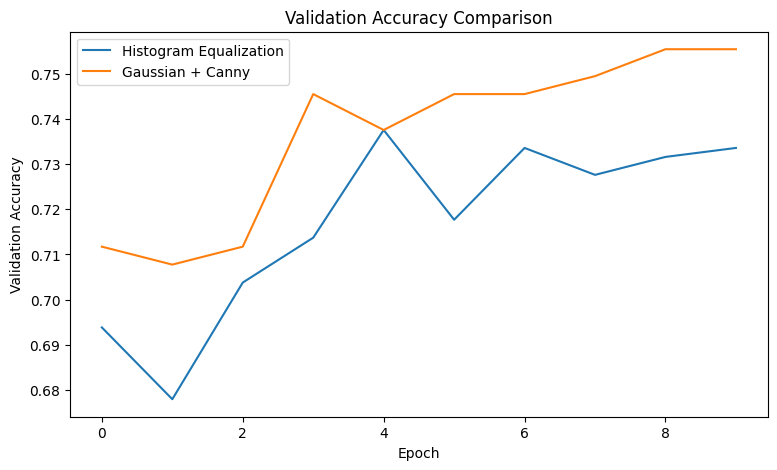

In [28]:
# ============================================================
# 8. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

#plt.plot(original_history.history["val_accuracy"], label="Original")
#plt.plot(gaussian_history.history["val_accuracy"], label="Gaussian")
plt.plot(hist_history.history["val_accuracy"], label="Histogram Equalization")
plt.plot(canny_history.history["val_accuracy"], label="Gaussian + Canny")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

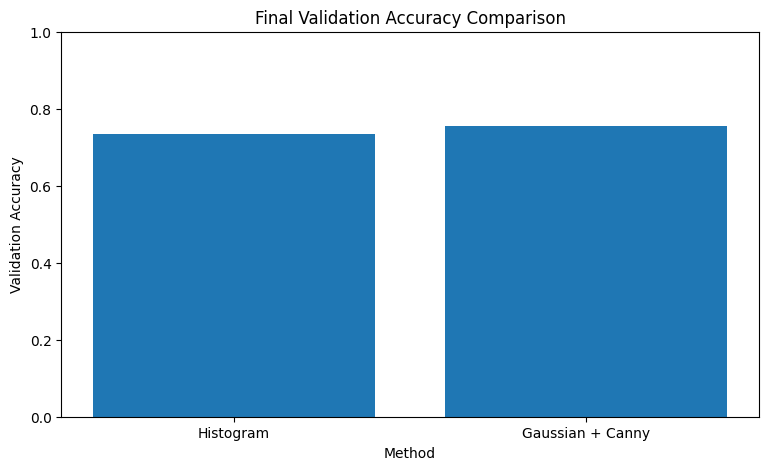

In [30]:
methods = [
    #"Original",
    #"Gaussian",
    "Histogram",
    "Gaussian + Canny"
]

accuracies = [
    #original_acc,
    #gaussian_acc,
    hist_acc,
    canny_acc
]

plt.figure(figsize=(9, 5))
plt.bar(methods, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.xlabel("Method")
plt.ylabel("Validation Accuracy")
plt.ylim(0, 1)

plt.show()